In [4]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [5]:
df = pd.read_csv('fraudTrain.csv')

In [6]:
df.sample(5)

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
122438,122438,2019-03-09 21:38:17,4260128500325,fraud_Morissette LLC,entertainment,114.63,Whitney,Gallagher,F,0374 Courtney Islands Apt. 400,...,37.2409,-82.7696,230,"Conservation officer, historic buildings",1997-08-04,0a0c19d08b936a6ee0c3aaeb9c794a08,1331329097,36.454867,-83.055807,0
396184,396184,2019-06-30 01:30:39,38199021865320,"fraud_Stanton, Jakubowski and Baumbach",shopping_net,90.72,Jesse,Roberts,M,8415 Vaughn Squares Apt. 788,...,43.1960,-72.3001,477,Naval architect,1988-04-15,629dfec9d5ce776503cc3327b3efa6de,1341019839,43.865038,-73.231955,0
963404,963404,2020-01-23 20:39:25,3501942333500073,fraud_Schuppe LLC,entertainment,148.46,Lori,Bishop,F,08056 Alvarado Club Suite 699,...,33.8155,-112.1202,1312922,Counselling psychologist,1999-11-30,80fa371a315a02c5064601c4d7fd6ca2,1358973565,33.079778,-112.660104,0
572796,572796,2019-08-31 17:22:37,3513506355699497,"fraud_Cronin, Kshlerin and Weber",health_fitness,10.37,Sarah,Adams,F,5654 Peterson Land,...,32.4122,-90.1207,24645,"Scientist, clinical (histocompatibility and im...",1966-05-29,a80a365bd526a6d5e1ab4d1c776f8a09,1346433757,32.772754,-90.839218,0
676337,676337,2019-10-14 23:03:18,370818583810103,"fraud_Ritchie, Oberbrunner and Cremin",travel,8.56,John,Davis,M,9670 Monroe Junctions,...,39.9373,-79.1865,3684,General practice doctor,1976-01-10,82357797656a5feb8ba443f24da27700,1350255798,40.049239,-78.298384,1


In [7]:
df.shape

(1296675, 23)

In [8]:
df.isnull().sum()

Unnamed: 0               0
trans_date_trans_time    0
cc_num                   0
merchant                 0
category                 0
amt                      0
first                    0
last                     0
gender                   0
street                   0
city                     0
state                    0
zip                      0
lat                      0
long                     0
city_pop                 0
job                      0
dob                      0
trans_num                0
unix_time                0
merch_lat                0
merch_long               0
is_fraud                 0
dtype: int64

In [9]:
df['is_fraud'].value_counts()

is_fraud
0    1289169
1       7506
Name: count, dtype: int64

In [10]:
print(f" Fraud % : {df['is_fraud'].mean() * 100:.2f}%")
print(f" Non Fraud % : {(1 - df['is_fraud'].mean()) * 100:.2f}%")

 Fraud % : 0.58%
 Non Fraud % : 99.42%


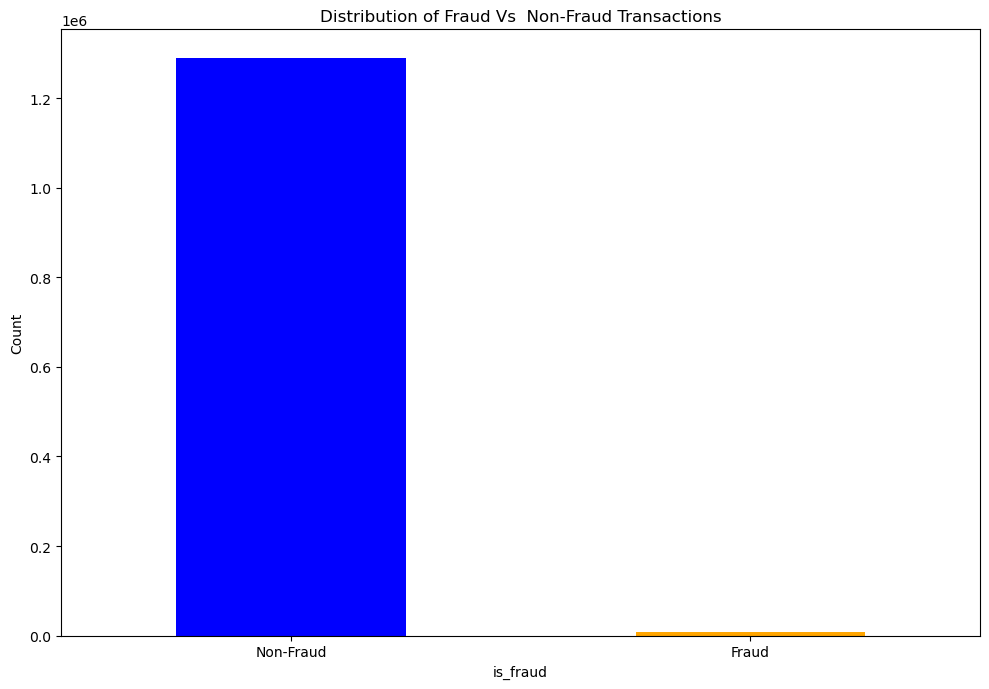

In [11]:
plt.figure(figsize=(10,7))
df['is_fraud'].value_counts().plot(kind='bar',color=['blue','orange'])
plt.title('Distribution of Fraud Vs  Non-Fraud Transactions')
plt.ylabel('Count')
plt.xticks(ticks=[0,1], labels=['Non-Fraud','Fraud'], rotation=0)
plt.tight_layout()
plt.show()  

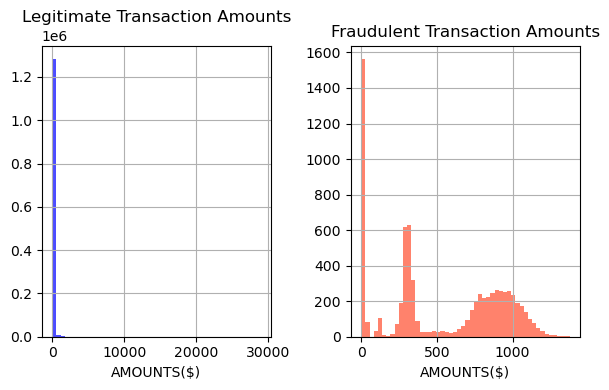

In [12]:
plt.figure(figsize=(6,4))
plt.subplot(1,2,1)
df[df['is_fraud']==0]['amt'].hist(bins=50, color='blue', alpha=0.7)
plt.title('Legitimate Transaction Amounts')
plt.xlabel('AMOUNTS($)')

plt.subplot(1,2,2)
df[df['is_fraud']==1]['amt'].hist(bins=50,color='tomato',alpha=0.8)
plt.title('Fraudulent Transaction Amounts')
plt.xlabel('AMOUNTS($)')
plt.tight_layout()
plt.show()

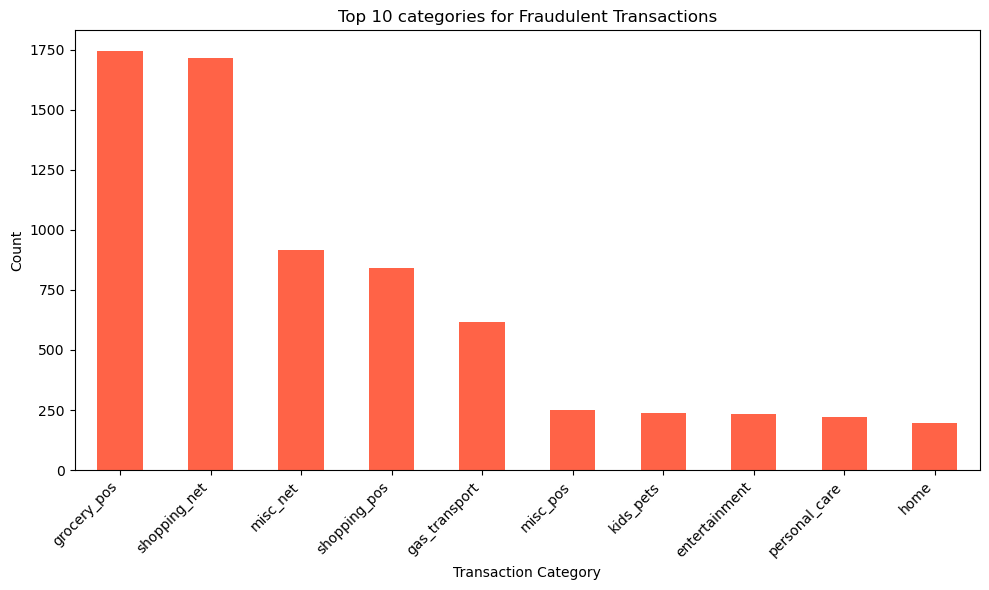

In [13]:
fraud_by_category= df[df['is_fraud']==1]['category'].value_counts().head(10)
plt.figure(figsize=(10,6))
fraud_by_category.plot(kind='bar', color='tomato')
plt.xlabel('Transaction Category')
plt.ylabel('Count')
plt.title('Top 10 categories for Fraudulent Transactions')
plt.xticks(rotation=45,ha='right')
plt.tight_layout()
plt.show()

In [14]:
df1=pd.read_csv('fraudTest.csv')
df1.head()

,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,0,2020-06-21 12:14:25,2291163933867244,fraud_Kirlin and Sons,personal_care,2.86,Jeff,Elliott,M,351 Darlene Green,...,33.9659,-80.9355,333497,Mechanical engineer,1968-03-19,2da90c7d74bd46a0caf3777415b3ebd3,1371816865,33.986391,-81.200714,0
1,1,2020-06-21 12:14:33,3573030041201292,fraud_Sporer-Keebler,personal_care,29.84,Joanne,Williams,F,3638 Marsh Union,...,40.3207,-110.4360,302,"Sales professional, IT",1990-01-17,324cc204407e99f51b0d6ca0055005e7,1371816873,39.450498,-109.960431,0
2,2,2020-06-21 12:14:53,3598215285024754,"fraud_Swaniawski, Nitzsche and Welch",health_fitness,41.28,Ashley,Lopez,F,9333 Valentine Point,...,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,c81755dbbbea9d5c77f094348a7579be,1371816893,40.495810,-74.196111,0
3,3,2020-06-21 12:15:15,3591919803438423,fraud_Haley Group,misc_pos,60.05,Brian,Williams,M,32941 Krystal Mill Apt. 552,...,28.5697,-80.8191,54767,Set designer,1987-07-25,2159175b9efe66dc301f149d3d5abf8c,1371816915,28.812398,-80.883061,0
4,4,2020-06-21 12:15:17,3526826139003047,fraud_Johnston-Casper,travel,3.19,Nathan,Massey,M,5783 Evan Roads Apt. 465,...,44.2529,-85.0170,1126,Furniture designer,1955-07-06,57ff021bd3f328f8738bb535c302a31b,1371816917,44.959148,-85.884734,0


In [15]:
df['split']='train'
df1['split']='test'
final = pd.concat([df,df1],ignore_index=True)

In [16]:
final['trans_date_trans_time']=pd.to_datetime(final['trans_date_trans_time'])
final['hour']=final['trans_date_trans_time'].dt.hour
final['day']=final['trans_date_trans_time'].dt.day
final['month']=final['trans_date_trans_time'].dt.month
final['weekday']=final['trans_date_trans_time'].dt.weekday

final['dob']=pd.to_datetime(final['dob'])
final['age']=(final['trans_date_trans_time']- final['dob']).dt.days // 365
final[['hour','day','month','weekday','age']].head()

,hour,day,month,weekday,age
0,0,1,1,1,30
1,0,1,1,1,40
2,0,1,1,1,56
3,0,1,1,1,52
4,0,1,1,1,32


In [17]:
drop_cols=['Unnamed: 0', 'trans_date_trans_time', 'cc_num', 'merchant',
    'first', 'last', 'street', 'city', 'state', 'zip',
    'dob', 'trans_num', 'unix_time', 'split']

final.drop(columns=drop_cols,inplace=True,errors='ignore')

In [18]:
cat_cols=final.select_dtypes(include='object').columns.tolist()
cat_cols=[c for c in cat_cols if c not in ['is_fraud']]

In [19]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in cat_cols:
    final[col]=le.fit_transform(final[col].astype(str))
final.head()

,category,amt,gender,lat,long,city_pop,job,merch_lat,merch_long,is_fraud,hour,day,month,weekday,age
0,8,4.97,0,36.0788,-81.1781,3495,372,36.011293,-82.048315,0,0,1,1,1,30
1,4,107.23,0,48.8878,-118.2105,149,431,49.159047,-118.186462,0,0,1,1,1,40
2,0,220.11,1,42.1808,-112.2620,4154,308,43.150704,-112.154481,0,0,1,1,1,56
3,2,45.00,1,46.2306,-112.1138,1939,330,47.034331,-112.561071,0,0,1,1,1,52
4,9,41.96,1,38.4207,-79.4629,99,116,38.674999,-78.632459,0,0,1,1,1,32


In [20]:
train_data = final[:len(df)]
test_data = final[len(df1):]

In [21]:
X_train= train_data.drop(columns=['is_fraud'])
y_train= train_data['is_fraud']

X_test= test_data.drop(columns=['is_fraud'])
y_test= test_data['is_fraud']   


print("Train:",X_train.shape,y_train.shape)

print("Test",X_test.shape,y_test.shape)

Train: (1296675, 14) (1296675,)
Test (1296675, 14) (1296675,)


In [22]:
from sklearn.utils import resample

In [23]:
balanced = pd.concat([X_train,y_train],axis=1)

fraud = balanced[balanced['is_fraud']==1]
legit = balanced[balanced['is_fraud']==0]   

legit_downsampled = resample(legit,
                             replace=False,
                            n_samples=len(fraud),
                           random_state=42
                           )                      

final_balanced = pd.concat([fraud,legit_downsampled])
final_balanced = final_balanced.sample(frac=1,random_state=42)

X_train_bal =final_balanced.drop(columns=['is_fraud'])
y_train_bal = final_balanced['is_fraud']

In [24]:
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve
)

In [67]:
from imblearn.over_sampling import SMOTE
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [68]:
scaler = StandardScaler()
X_train_scale = scaler.fit_transform(X_train_bal)
X_test_scale = scaler.transform(X_test) 

In [69]:
lr = LogisticRegression(max_iter = 1000 , random_state=42)
lr.fit(X_train_scale,y_train_bal)
y_pred = lr.predict(X_test_scale)
y_prob_lr = lr.predict_proba(X_test_scale)[:,1]
print(f"Accuracy: {accuracy_score(y_test,y_pred):.4f}")
print(f"ROC-ACC: {roc_auc_score(y_test,y_prob_lr):.4f}")

Accuracy: 0.9422
ROC-ACC: 0.8668


In [70]:
dt = DecisionTreeClassifier(max_depth = 10, random_state=42)
dt.fit(X_train_bal , y_train_bal)
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]
print("=== Decision Tree ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_dt):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_dt):.4f}")
print()
print(classification_report(y_test, y_pred_dt, target_names=['Legitimate', 'Fraud']))


=== Decision Tree ===
Accuracy : 0.9747
ROC-AUC  : 0.9878

              precision    recall  f1-score   support

  Legitimate       1.00      0.97      0.99   1290265
       Fraud       0.16      0.94      0.27      6410

    accuracy                           0.97   1296675
   macro avg       0.58      0.96      0.63   1296675
weighted avg       1.00      0.97      0.98   1296675



In [71]:
rf = RandomForestClassifier(n_estimators=100,max_depth= 10 , random_state=42 , n_jobs =-1)
rf.fit(X_train_bal , y_train_bal)
y_pred_rf=rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]
print("=== Random Forest ===")
print(f"Accuracy : {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"ROC-AUC  : {roc_auc_score(y_test, y_prob_rf):.4f}")
print()
print(classification_report(y_test, y_pred_rf, target_names=['Legitimate', 'Fraud']))



=== Random Forest ===
Accuracy : 0.9784
ROC-AUC  : 0.9873

              precision    recall  f1-score   support

  Legitimate       1.00      0.98      0.99   1290265
       Fraud       0.17      0.89      0.29      6410

    accuracy                           0.98   1296675
   macro avg       0.59      0.94      0.64   1296675
weighted avg       1.00      0.98      0.99   1296675



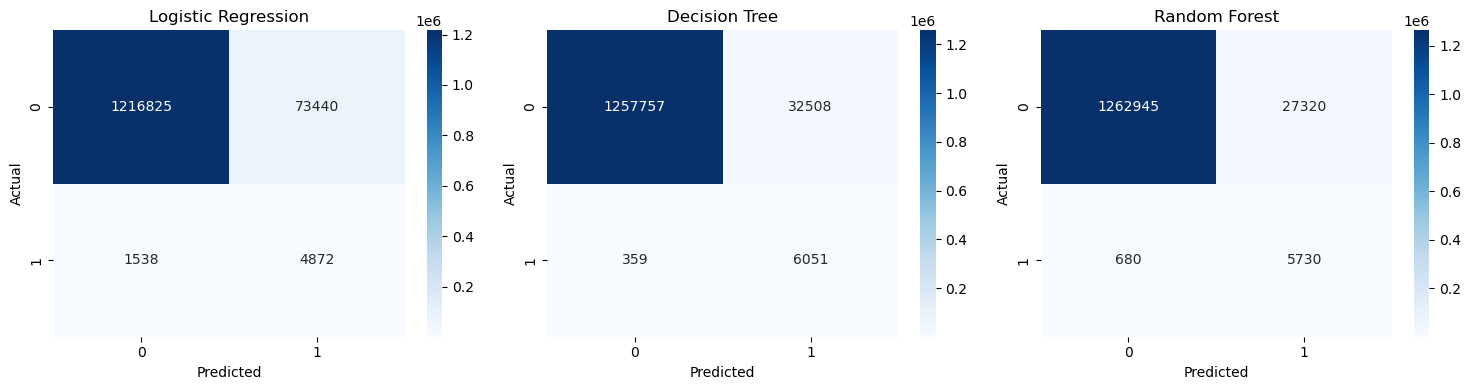

In [72]:
fig,axes  = plt.subplots(1,3,figsize=(15,4))
names = ["Logistic Regression" , "Decision Tree" , "Random Forest" ]
preds = [ y_pred, y_pred_dt , y_pred_rf ]

for i in range (3):
    cm = confusion_matrix(y_test, preds[i])
    sns.heatmap(cm,annot=True,fmt ='d',cmap='Blues', ax=axes[i])
    axes[i].set_title(names[i])
    axes[i].set_xlabel('Predicted')      
    axes[i].set_ylabel('Actual')
plt.tight_layout()  
plt.show()


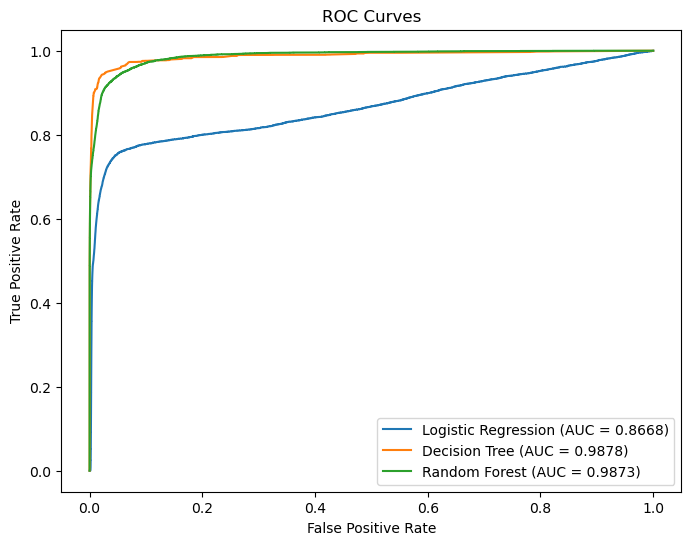

In [73]:
plt.figure(figsize=(8,6))
for name,y_prob in [("Logistic Regression", y_prob_lr), 
                    ("Decision Tree", y_prob_dt),
                    ("Random Forest", y_prob_rf)]:
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc  = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.show()


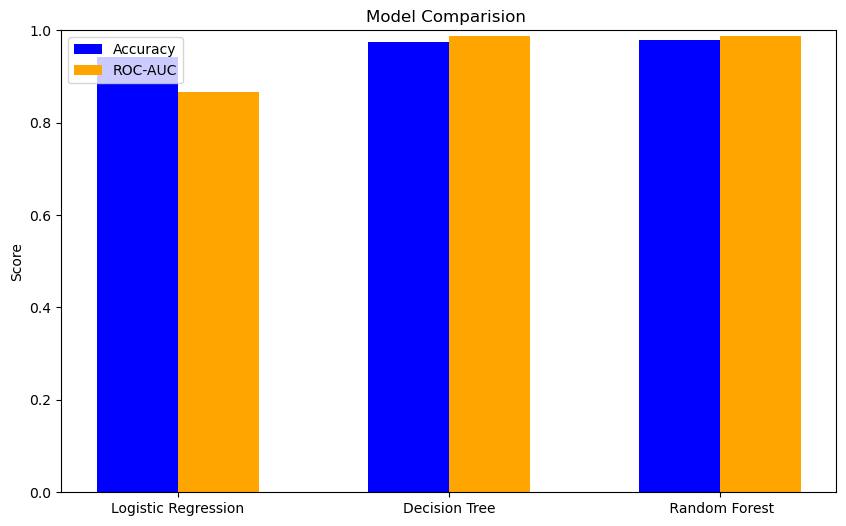

In [74]:
models = ["Logistic Regression", "Decision Tree", " Random Forest"]

accuracy= [accuracy_score(y_test,y_pred),
            accuracy_score(y_test, y_pred_dt), 
            accuracy_score(y_test, y_pred_rf)  
           ]

auc = [roc_auc_score(y_test,y_prob_lr),
       roc_auc_score(y_test,y_prob_dt),
       roc_auc_score(y_test,y_prob_rf)  
       ]

x = np.arange(len(models))
w = 0.3 
plt.figure(figsize=(10,6))
plt.bar(x-w/2, accuracy, width=w, label='Accuracy', color='blue')
plt.bar(x+w/2, auc, width=w, label='ROC-AUC', color='orange')
plt.xticks(x, models)
plt.ylabel('Score')    
plt.ylim(0,1)
plt.title("Model Comparision ")
plt.legend()
plt.show()

C:\Users\pranj\AppData\Local\Temp\ipykernel_19364\694418990.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')


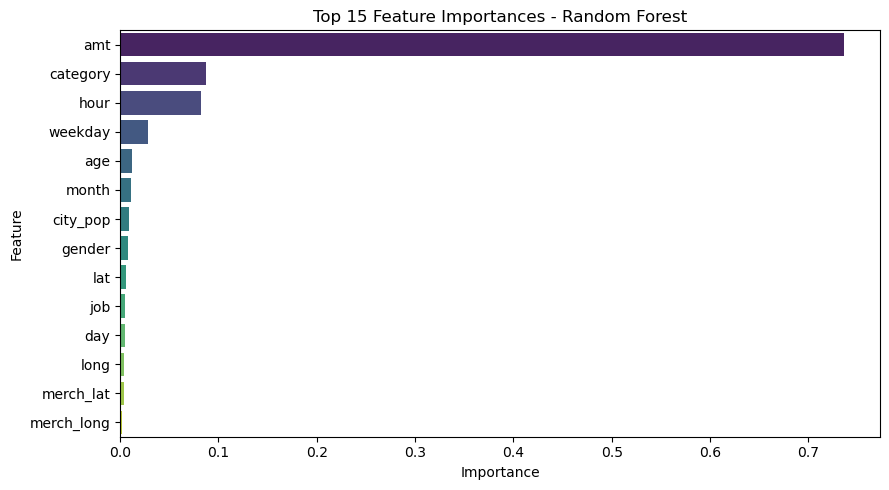

In [75]:
feature_names = X_train_bal.columns.tolist()
importances   = rf.feature_importances_

feat_imp_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feat_imp_df = feat_imp_df.sort_values('Importance', ascending=False).head(15)

plt.figure(figsize=(9, 5))
sns.barplot(x='Importance', y='Feature', data=feat_imp_df, palette='viridis')
plt.title('Top 15 Feature Importances - Random Forest')
plt.tight_layout()
plt.show()

##  Conclusion

| Model               | What it does well                        | Limitation                        |
|---------------------|------------------------------------------|-----------------------------------|
| Logistic Regression | Fast, interpretable, good baseline       | Linear, may miss complex patterns |
| Decision Tree       | Easy to visualize, captures nonlinearity | Can overfit if depth not limited  |
| Random Forest       | Most accurate, handles noise well        | Slower to train, less interpretable|

**Best Model: Random Forest** — highest AUC, best precision-recall for fraud class.

###  Key Observations:
- The dataset is **highly imbalanced** (~99% legit) — undersampling helped training
- `amt` (transaction amount) and derived time features (`hour`, `age`) are top predictors
- Categories like `shopping_net`, `misc_net`, `grocery_pos` had the most fraud cases
- **ROC-AUC** is a better metric than accuracy here due to class imbalance


In [80]:
import joblib

joblib.dump(rf, "fraud_model.pkl")
joblib.dump(scaler, "fraud_scaler.pkl")
joblib.dump(X_train_bal.columns.tolist(), "feature_cols.pkl")

['feature_cols.pkl']

In [81]:
def predict_fraud(transaction_data):
    pred = rf.predict(transaction_data)
    return "FRAUD" if pred[0]==1 else "LEGIT " 

In [82]:
print(type(scaler))

<class 'sklearn.preprocessing._data.StandardScaler'>
